In [1]:
import pandas as pd
import numpy as np
import pickle
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
with open('data/processed/X_train.pkl', 'rb') as f:
    X_train = pickle.load(f)

with open('data/processed/X_test.pkl', 'rb') as f:
    X_test = pickle.load(f)

with open('data/processed/y_train.pkl', 'rb') as f:
    y_train = pickle.load(f)

with open('data/processed/y_test.pkl', 'rb') as f:
    y_test = pickle.load(f)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (564, 56)
Test set: (96, 56)


In [3]:
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [4]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC-AUC:", roc_auc)

Logistic Regression Results:
Accuracy: 0.9375
Precision: 0.88
Recall: 0.88
F1 Score: 0.88
ROC-AUC: 0.9797183098591549


In [6]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96        71
           1       0.88      0.88      0.88        25

    accuracy                           0.94        96
   macro avg       0.92      0.92      0.92        96
weighted avg       0.94      0.94      0.94        96



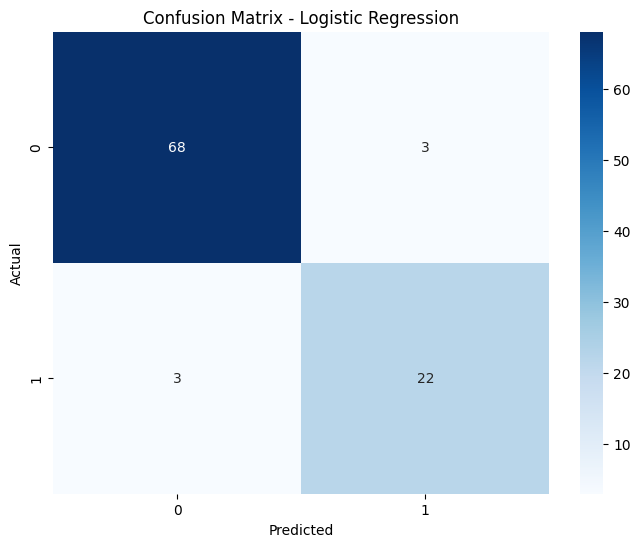

In [7]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

In [8]:
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': model.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

feature_importance.head(10)

,feature,coefficient
5,is_absent_frequently,2.555827
42,Topic_Chemistry,2.029725
6,parent_engaged,-1.514377
40,Topic_Arabic,1.242873
20,NationalITy_SaudiArabia,-0.915442
54,Relation_Father,0.881491
53,Semester_S,0.826528
43,Topic_English,-0.771847
30,PlaceofBirth_KuwaIT,0.765712
16,NationalITy_KW,0.754053


In [ ]:
with open('models/logistic_regression.pkl', 'wb') as f:
    pickle.dump(model, f)